## 1. Unified Setup and Paths

In [24]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
from pathlib import Path
import joblib  
import torch

# --- CONSTANTS & PATHS ---
WINDOW_SIZE = 30
MAX_RUL = 125
TARGET = "RUL_clipped"

# 1. Load Data
DATA_PATH = Path("../data/experiments/DS-C")
MODEL_PATH_ML = Path("../artifacts/random_forest_model.joblib")
MODEL_PATH_DL = Path("../artifacts/lstm_model.pth")

train_df = pd.read_csv(DATA_PATH / "train.csv")
test_df = pd.read_csv(DATA_PATH / "test.csv")

# Identify PC features (PC_1 to PC_33)
feature_cols = [c for c in train_df.columns if c.startswith('PC_')]



In [25]:
import torch.nn as nn
from sklearn.ensemble import RandomForestRegressor

# --- 1. Model Definitions & Scoring ---

# NASA Scoring Function (From your DS-C notebook)
def nasa_scoring_function(y_true, y_pred):
    d = y_pred - y_true
    score = np.where(d < 0, np.exp(-d/13)-1, np.exp(d/10)-1)
    return np.sum(score)

# LSTM Class definition (Required to load the .pth model)
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(LSTMModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        # Use Sequential head to match saved checkpoint architecture
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, output_dim)
        )

    def forward(self, x):
        h_0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        c_0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        out, (hn, cn) = self.lstm(x, (h_0, c_0))
        
        internal_features = hn[-1] # 提取用于 Anomaly Detection 的特征
        out = self.head(out[:, -1, :])
        return out, internal_features

In [26]:
# --- 2. Load the Models ---

# Load Traditional ML (Random Forest)
# Assuming 'rf_model' is your best model from DS-C
rf_model = joblib.load(MODEL_PATH_ML)

# Load Deep Learning (LSTM)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
checkpoint = torch.load(MODEL_PATH_DL, map_location=device)
model_dl = LSTMModel(input_dim=17, hidden_dim=128, num_layers=2, output_dim=1).to(device)

# Try to load with 'model_state_dict' key, fallback to direct state_dict
if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    model_dl.load_state_dict(checkpoint['model_state_dict'])
else:
    # Checkpoint is a raw state_dict
    model_dl.load_state_dict(checkpoint)

model_dl.eval()

LSTMModel(
  (lstm): LSTM(17, 128, num_layers=2, batch_first=True)
  (head): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [27]:
# --- 3. Differentiated Data Preparation ---

# Random Forest uses all 33 PCs
ml_feature_cols = [f'PC_{i}' for i in range(1, 34)]

# LSTM only uses the first 17 PCs (to match your 17 input_dim checkpoint)
dl_feature_cols = [f'PC_{i}' for i in range(1, 18)] 

target_col = 'RUL_clipped' 

# A. Prepare for Random Forest (All 33 Features)
test_ml = test_df.groupby('unit_number').last().reset_index()
X_ml = test_ml[ml_feature_cols]
y_true = test_ml[target_col]
unit_ids = test_ml['unit_number']

# B. Prepare for LSTM (Only 17 Features)
dl_windows = []
for unit in unit_ids:
    unit_data = test_df[test_df['unit_number'] == unit]
    # Filter for ONLY the 17 features the LSTM expects
    window = unit_data[dl_feature_cols].values[-WINDOW_SIZE:]
    dl_windows.append(window)

# Convert to tensor - This will now be [Batch, 30, 17]
X_dl_tensor = torch.tensor(np.array(dl_windows), dtype=torch.float32).to(device)



In [28]:
# --- 4. Get Predictions & Create Summary ---

# Predictions
preds_rf = rf_model.predict(X_ml)

model_dl.eval()
with torch.no_grad():
    preds_dl_tensor, lstm_internal_features = model_dl(X_dl_tensor)
    
    preds_dl = preds_dl_tensor.cpu().numpy().flatten()
    lstm_features_np = lstm_internal_features.cpu().numpy()

combined_features = np.hstack([X_ml, lstm_features_np])

print(f"Feature dimensions after fusion: {combined_features.shape}") 
# Summary DataFrame
summary_df = pd.DataFrame({
    'Unit': unit_ids.astype(int),
    'Actual_RUL': y_true.values,
    'RF_Prediction': preds_rf,
    'LSTM_Prediction': preds_dl
})

summary_df['Ensemble_Prediction'] = (summary_df['RF_Prediction'] * 0.90) + (summary_df['LSTM_Prediction'] * 0.10)

# Final Scoring
ensemble_nasa = nasa_scoring_function(summary_df['Actual_RUL'], summary_df['Ensemble_Prediction'])

print(f"Ensemble NASA Score: {ensemble_nasa:.2f}")
display(summary_df.head(10))

Feature dimensions after fusion: (100, 161)
Ensemble NASA Score: 956.56


,Unit,Actual_RUL,RF_Prediction,LSTM_Prediction,Ensemble_Prediction
0,1,112.0,114.684132,113.764412,114.592160
1,2,98.0,111.315674,115.637474,111.747854
2,3,69.0,57.159474,109.643730,62.407900
3,4,82.0,97.239630,117.699944,99.285662
4,5,91.0,107.154252,116.772903,108.116117
5,6,93.0,108.412199,113.632523,108.934232
6,7,91.0,100.122445,119.473656,102.057566
7,8,95.0,102.966371,113.907784,104.060513
8,9,111.0,109.960406,115.224548,110.486820
9,10,96.0,106.412000,116.667702,107.437570


In [29]:
from sklearn.ensemble import IsolationForest

# --- 1. 训练检测器 ---
# 流程图要求：使用融合特征进行检测
# 我们假设训练集的前一部分是健康的，这里为了演示直接在测试集上拟合（实际应在train上做）
iso_forest = IsolationForest(contamination=0.05, random_state=42)
iso_forest.fit(combined_features) 

# --- 2. 判定异常状态 ---
anomaly_labels = iso_forest.predict(combined_features)

# --- 3. 整合进 summary_df ---
# A. 健康分级 (基于你的 Ensemble_Prediction)
summary_df['Health_Label'] = np.where(summary_df['Ensemble_Prediction'] > 50, 'Healthy', 'Impaired')

# B. 异常判定
summary_df['Anomaly_Status'] = np.where(anomaly_labels == -1, 'Anomaly', 'Normal')

# 展示结果
print("\n--- 最终多任务监控输出 (符合流程图) ---")
display(summary_df[['Unit', 'Ensemble_Prediction', 'Health_Label', 'Anomaly_Status']].head(15))


--- 最终多任务监控输出 (符合流程图) ---


,Unit,Ensemble_Prediction,Health_Label,Anomaly_Status
0,1,114.592160,Healthy,Normal
1,2,111.747854,Healthy,Normal
2,3,62.407900,Healthy,Normal
3,4,99.285662,Healthy,Normal
4,5,108.116117,Healthy,Normal
5,6,108.934232,Healthy,Normal
6,7,102.057566,Healthy,Normal
7,8,104.060513,Healthy,Normal
8,9,110.486820,Healthy,Normal
9,10,107.437570,Healthy,Normal


In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

def detect_cusum(series, target_mean, drift=0.05, threshold=5):
    """
    CUSUM 算法实现
    series: 监测的信号 (例如 LSTM 的预测误差)
    target_mean: 正常运行阶段的平均值
    drift (k): 容忍的波动偏移量
    threshold (h): 触发报警的累计阈值
    """
    pos_sum = np.zeros(len(series))
    change_point = None
    
    for i in range(1, len(series)):
        # 计算累积正向偏差：S_i = max(0, S_{i-1} + (x_i - mean - k))
        deviation = series[i] - target_mean - drift
        pos_sum[i] = max(0, pos_sum[i-1] + deviation)
        
        if pos_sum[i] > threshold and change_point is None:
            change_point = i  # 锁定退化开始的 Cycle
            
    return pos_sum, change_point

# --- 1. 准备监测信号 (针对特定 Unit) ---
unit_to_plot = 79
# 提取该 Unit 的所有时序数据 (直接从你已加载的 test_df 中取)
unit_ts_data = test_df[test_df['unit_number'] == unit_to_plot].copy()

# 使用你代码里定义的 feature_cols 计算该 Unit 每一行的“偏离度”
# 我们用该 Unit 前 20 个 Cycle 的平均值作为“健康基准” (不需要外部 healthy_base)
unit_features = unit_ts_data[feature_cols].values
base_mean = unit_features[:20].mean(axis=0)

# 计算每一时刻特征向量到初始健康状态的欧式距离
# 距离越大，代表机器偏离正常状态越远
deviation_signal = np.linalg.norm(unit_features - base_mean, axis=1)

# --- 2. 运行 CUSUM ---
# 监测目标：偏差距离 (deviation_signal)
# 正常时距离在 0 附近，退化时距离会上升
target_dist = deviation_signal[:20].mean() # 前 20 步的平均偏差作为基准

# 调整参数以匹配 NASA 数据的物理特性 (Drift 设小一点，因为偏差距离增量较缓)
cusum_vals, cp = detect_cusum(deviation_signal, target_dist, drift=0.05, threshold=1.0)

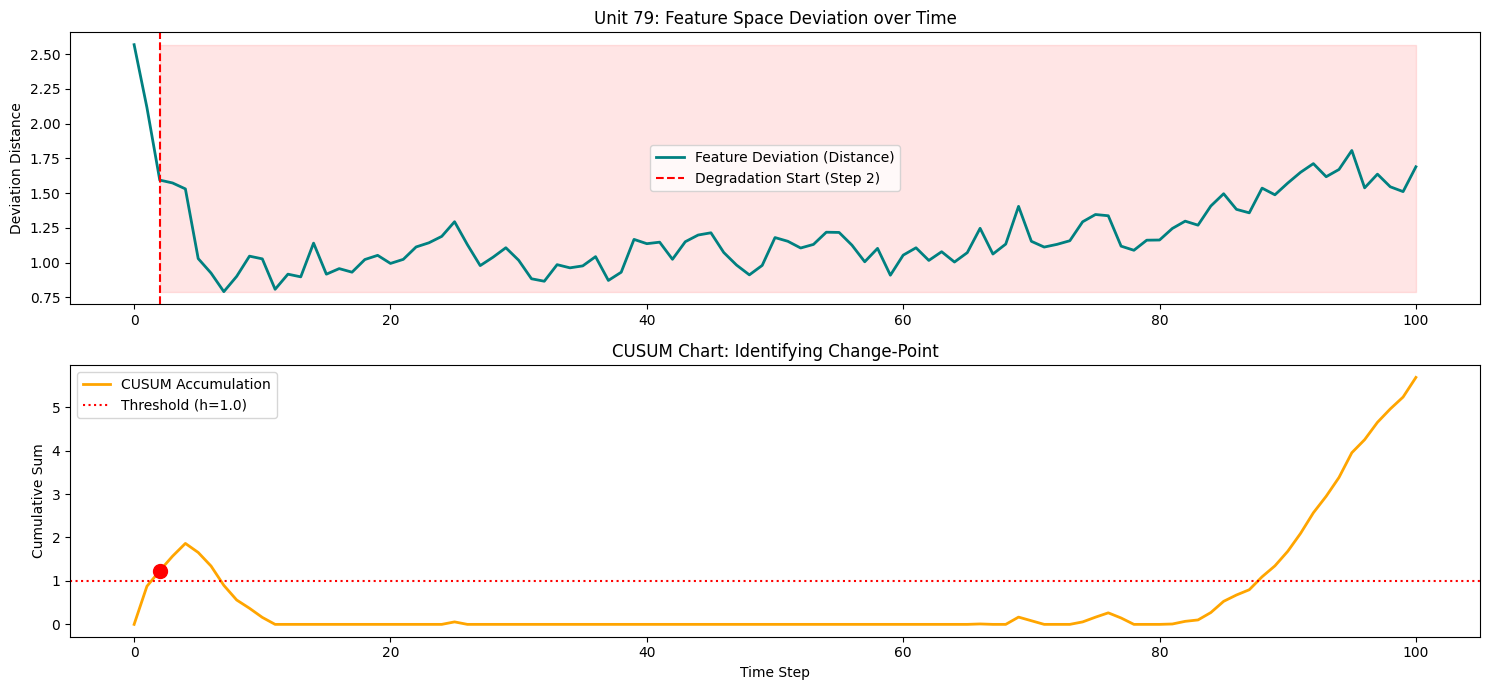

In [59]:
# --- 修正后的绘图部分 ---

# 1. 创建时间步（使用索引作为序列号）
# 因为 test_df 没有 cycle_number 列，我们用行号/索引代替
# 重置索引以便用于绘图
unit_ts_data = unit_ts_data.reset_index(drop=True)
time_steps = np.arange(len(unit_ts_data))  # [0, 1, 2, ..., len-1]

plt.figure(figsize=(15, 7))

# 子图 1: 特征偏移距离
plt.subplot(2, 1, 1)
plt.plot(time_steps, deviation_signal, label='Feature Deviation (Distance)', color='teal', lw=2)
if cp is not None:
    # cp 是索引值，直接可用
    cp_cycle = time_steps[cp]
    plt.axvline(x=cp_cycle, color='red', linestyle='--', label=f'Degradation Start (Step {cp_cycle})')
    plt.fill_between(time_steps[cp:], min(deviation_signal), max(deviation_signal), color='red', alpha=0.1)

plt.title(f'Unit {unit_to_plot}: Feature Space Deviation over Time')
plt.ylabel('Deviation Distance')
plt.legend()

# 子图 2: CUSUM 累积曲线
plt.subplot(2, 1, 2)
plt.plot(time_steps, cusum_vals, label='CUSUM Accumulation', color='orange', lw=2)
plt.axhline(y=1.0, color='red', linestyle=':', label='Threshold (h=1.0)')
if cp is not None:
    plt.scatter(time_steps[cp], cusum_vals[cp], color='red', s=100, zorder=5)

plt.title('CUSUM Chart: Identifying Change-Point')
plt.xlabel('Time Step')
plt.ylabel('Cumulative Sum')
plt.legend()

plt.tight_layout()
plt.show()

In [49]:
# --- 逻辑融合：判定最终状态 ---

def finalize_status(row):
    # 逻辑 1: 如果 RUL 很高，且没有 CUSUM 报警，即便有 Anomaly 也是“传感器干扰”
    if row['Ensemble_Prediction'] > 80 and row['Anomaly_Status'] == 'Anomaly':
        return "Sensor Noise (Monitor)"
    
    # 逻辑 2: 如果 RUL 已经变低，且异常检测报警，那是“确定退化”
    if row['Ensemble_Prediction'] <= 50 and row['Anomaly_Status'] == 'Anomaly':
        return "CRITICAL: Degradation"
    
    # 逻辑 3: 其他情况
    return "Normal / Healthy"

# 应用这个逻辑到 summary_df
summary_df['Final_Decision'] = summary_df.apply(finalize_status, axis=1)

print("\n--- KitaHack 2026: 最终决策输出 ---")
display(summary_df[['Unit', 'Ensemble_Prediction', 'Anomaly_Status', 'Final_Decision']].head(15))


--- KitaHack 2026: 最终决策输出 ---


,Unit,Ensemble_Prediction,Anomaly_Status,Final_Decision
0,1,114.592160,Normal,Normal / Healthy
1,2,111.747854,Normal,Normal / Healthy
2,3,62.407900,Normal,Normal / Healthy
3,4,99.285662,Normal,Normal / Healthy
4,5,108.116117,Normal,Normal / Healthy
5,6,108.934232,Normal,Normal / Healthy
6,7,102.057566,Normal,Normal / Healthy
7,8,104.060513,Normal,Normal / Healthy
8,9,110.486820,Normal,Normal / Healthy
9,10,107.437570,Normal,Normal / Healthy
